In [31]:
device="cuda"

In [32]:
import os
import random
import numpy as np
import copy
from packboost.core import PackBoost
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import time

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
random.seed(SEED)
np.random.seed(SEED)

try:
    import torch
    torch.manual_seed(SEED)
    torch.set_num_threads(1)
    torch.set_num_interop_threads(1)
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception:
    pass

rng_data = np.random.default_rng(SEED)
X = rng_data.integers(0, 4, (100000, 20), dtype=np.int8)
Xval = rng_data.integers(0, 4, (2000, 20), dtype=np.int8)
X_test = rng_data.integers(0, 4, (500, 20), dtype=np.int8)

def make_y(X_, rng_noise):
    # Spread signal across many dimensions with small interaction terms
    return (
        0.35 * X_[:, 0].astype(np.float32)
        + 0.28 * X_[:, 1].astype(np.float32)
        + 0.22 * X_[:, 2].astype(np.float32)
        + 0.010 * rng_noise.standard_normal(len(X_), dtype=np.float32)
    )

y = make_y(X, np.random.default_rng(SEED + 1))
yval = make_y(Xval, np.random.default_rng(SEED + 2))
y_test_true = make_y(X_test, np.random.default_rng(SEED + 3))

# Apply MinMaxScaler to scale y values to [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
y_scaled = scaler.fit_transform(y.reshape(-1, 1)).ravel()
yval_scaled = scaler.transform(yval.reshape(-1, 1)).ravel()
y_test_true_scaled = scaler.transform(y_test_true.reshape(-1, 1)).ravel()

# Bucketize into [0, 0.25, 0.5, 0.75, 1]
bins = [0, 0.25, 0.5, 0.75, 1.0]
labels = np.array([0.125, 0.375, 0.625, 0.875], dtype=np.float32)  # Use float array for labels

# Use pd.cut and convert labels properly
y_cat = pd.cut(y_scaled, bins=bins, labels=labels, include_lowest=True)
y = labels[y_cat.codes].astype(np.float32)

yval_cat = pd.cut(yval_scaled, bins=bins, labels=labels, include_lowest=True)
yval = labels[yval_cat.codes].astype(np.float32)

y_test_cat = pd.cut(y_test_true_scaled, bins=bins, labels=labels, include_lowest=True)
y_test_true = labels[y_test_cat.codes].astype(np.float32)

print(f"Preprocessed y - min: {y.min()}, max: {y.max()}")
print(f"Unique y values: {np.unique(y)}")

model = PackBoost(device=device)
start = time.time()
model.fit(
    X, y,
    Xv=Xval, Yv=yval,
    rounds=30,
    max_depth=8,
    nfolds=4,
    lr=1.0,
    seed=SEED,
    nfeatsets=2,
    encode_cut_device=device,
    L2=1_000.0,
    min_child_weight=200.0,
    min_split_gain=0.0,
)
end = time.time()
print(f"Training completed in {end - start:.2f} seconds")

Preprocessed y - min: 0.125, max: 0.875
Unique y values: [0.125 0.375 0.625 0.875]
Training completed in 0.11 seconds


## compare cpu vs gpu P

Pearson r : 0.9545
R²        : 0.8959


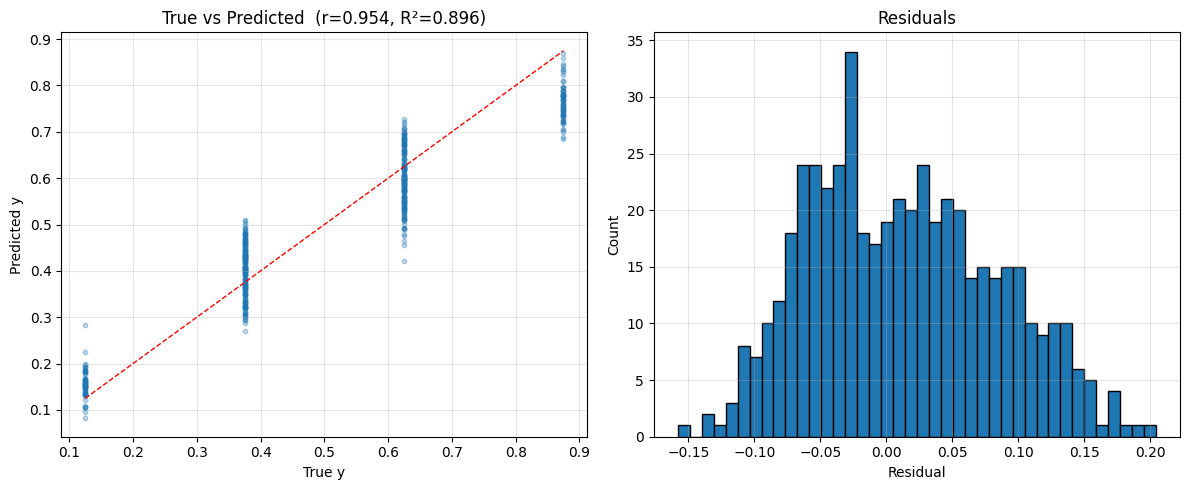

In [33]:
import matplotlib.pyplot as plt

preds = model.predict(X_test)
corr = np.corrcoef(preds, y_test_true)[0, 1]
ss_res = np.sum((y_test_true - preds) ** 2)
ss_tot = np.sum((y_test_true - y_test_true.mean()) ** 2)
r2 = 1.0 - ss_res / ss_tot

print(f"Pearson r : {corr:.4f}")
print(f"R²        : {r2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test_true, preds, alpha=0.3, s=10)
lo, hi = y_test_true.min(), y_test_true.max()
axes[0].plot([lo, hi], [lo, hi], 'r--', linewidth=1)
axes[0].set_xlabel("True y")
axes[0].set_ylabel("Predicted y")
axes[0].set_title(f"True vs Predicted  (r={corr:.3f}, R²={r2:.3f})")
axes[0].grid(True, alpha=0.3)

axes[1].hist(y_test_true - preds, bins=40, edgecolor='black')
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residuals")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()